### 1. Librerías

In [22]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

%matplotlib inline

### 2. Cargar el dataset

In [23]:
ruta_dataset = 'D:\\SEMESTRE2_2026\\IA INTELIGENCIA ARTIFICIAL\\1mer parcial\\cats and dogs\\cats_dogs'

rutas_cat = glob.glob(os.path.join(ruta_dataset, '**', 'cat', '*.wav'), recursive=True)
rutas_dog = glob.glob(os.path.join(ruta_dataset, '**', 'dog', '*.wav'), recursive=True)

print('Audios de gatos:', len(rutas_cat))
print('Audios de perros:', len(rutas_dog))

Audios de gatos: 125
Audios de perros: 85


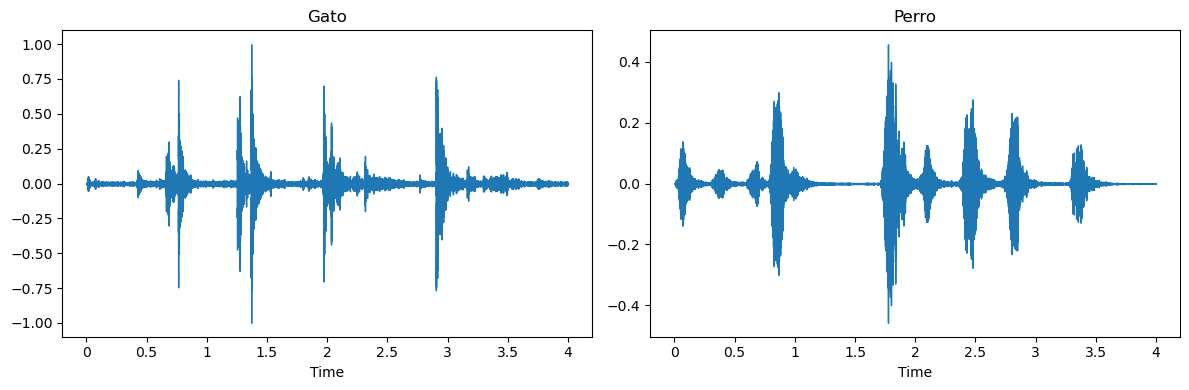

In [24]:
sr_objetivo = 16000
duracion_max = 4

ejemplo_cat, _ = librosa.load(rutas_cat[0], sr=sr_objetivo, duration=duracion_max)
ejemplo_dog, _ = librosa.load(rutas_dog[0], sr=sr_objetivo, duration=duracion_max)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
librosa.display.waveshow(ejemplo_cat, sr=sr_objetivo, ax=ax[0])
ax[0].set_title('Gato')
librosa.display.waveshow(ejemplo_dog, sr=sr_objetivo, ax=ax[1])
ax[1].set_title('Perro')
plt.tight_layout()
plt.show()

### 4. Extraer características (MFCC)
 Mel-Frequency Cepstral Coefficients (Coeficientes Cepstrales en las Frecuencias de Mel)

In [25]:
n_mfcc = 20

def extraer_caracteristicas(ruta):
    y, sr = librosa.load(ruta, sr=sr_objetivo, duration=duracion_max)
    y = librosa.util.fix_length(y, size=sr_objetivo*duracion_max)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)

rutas = rutas_cat + rutas_dog
etiquetas = [0]*len(rutas_cat) + [1]*len(rutas_dog)

X = np.array([extraer_caracteristicas(r) for r in rutas])
y = np.array(etiquetas)

print('X:', X.shape)
print('y:', y.shape)

X: (210, 20)
y: (210,)


### 5. Train Test


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

escalador = StandardScaler()
X_train = escalador.fit_transform(X_train)
X_test = escalador.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

### 6. Red neuronal

In [27]:
class RedAudio(nn.Module):
    def __init__(self, entrada):
        super().__init__()
        self.capa1 = nn.Linear(entrada, 16)
        self.capa2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoide = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.capa1(x))
        x = self.sigmoide(self.capa2(x))
        return x

torch.manual_seed(42)
modelo = RedAudio(X_train.shape[1])
print(modelo)

RedAudio(
  (capa1): Linear(in_features=20, out_features=16, bias=True)
  (capa2): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoide): Sigmoid()
)


### 7. Entrenamiento


In [28]:
criterio = nn.BCELoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)

epochs = 100
historial_loss = []

for epoch in range(1, epochs+1):
    optimizador.zero_grad()
    y_hat = modelo(X_train_t)
    loss = criterio(y_hat, y_train_t)
    loss.backward()
    optimizador.step()
    historial_loss.append(loss.item())
    if epoch % 20 == 0:
        print(f'Epoch {epoch}/{epochs} - Loss: {loss.item():.4f}')

Epoch 20/100 - Loss: 0.3839
Epoch 40/100 - Loss: 0.2646
Epoch 60/100 - Loss: 0.1902
Epoch 80/100 - Loss: 0.1322
Epoch 100/100 - Loss: 0.0862


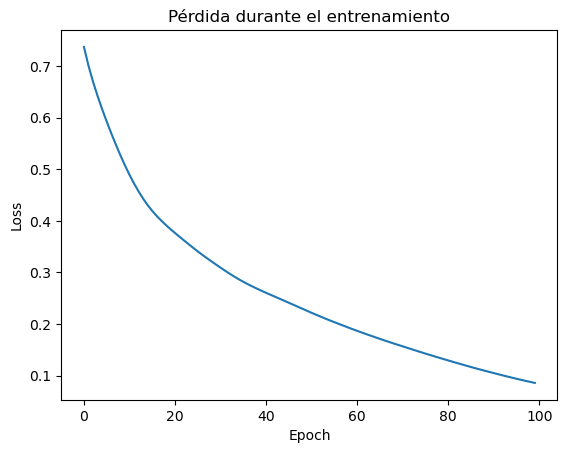

In [29]:
plt.plot(historial_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Pérdida durante el entrenamiento')
plt.show()

### 8. Evaluación con métricas de clasificación


In [30]:
with torch.no_grad():
    probs = modelo(X_test_t).numpy().ravel()

y_pred = (probs > 0.5).astype(int)

In [31]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.2f}')

Accuracy: 0.87


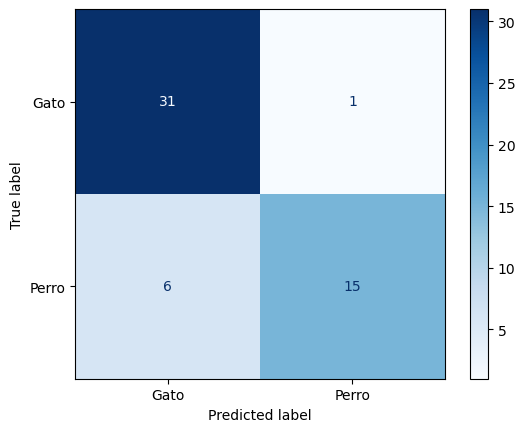

In [32]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Gato', 'Perro'])
disp.plot(cmap='Blues')
plt.show()

In [33]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')

Precision: 0.94
Recall: 0.71
F1-Score: 0.81


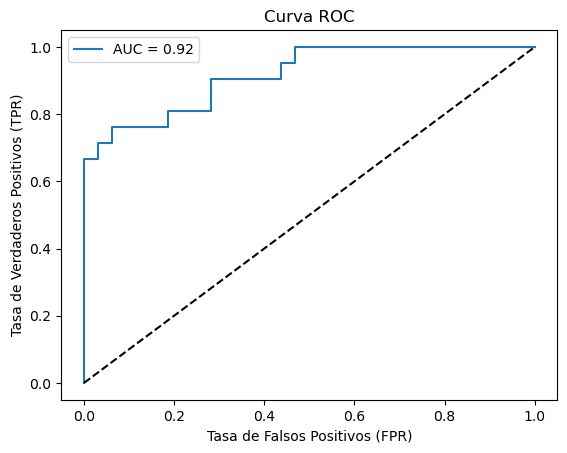

AUC: 0.92


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, umbrales = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

print(f'AUC: {auc:.2f}')

### 9. Conclusiones

- Se convirtió cada audio en un vector de 20 características (MFCC) para poder usarlo en una red neuronal.
- Se entrenó una red neuronal simple de una sola capa oculta, usando BCELoss y Adam.
- El Accuracy solo no es suficiente para saber si el modelo es bueno, por eso se revisan también Precision, Recall y F1-Score, que muestran mejor si el modelo confunde gatos con perros.